# 1. Khởi tạo Spark và Nạp dữ liệu 

In [2]:
from pyspark.sql import SparkSession

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("MovieRecommendation-EDA-Notebook") \
    .master("local[*]") \
    .getOrCreate()

# Nạp dữ liệu Parquet đã làm sạch (Đường dẫn lùi ra ngoài 2 thư mục để vào data)
rating_path = "../../data/processed_ratings.parquet"
item_path = "../../data/processed_items.parquet"

ratings_df = spark.read.parquet(rating_path)
items_df = spark.read.parquet(item_path)

# Nối 2 bảng để lấy tên phim và tạo View cho SQL
joined_df = ratings_df.join(items_df, on="movie_id", how="inner")
joined_df.createOrReplaceTempView("movies_ratings")

print("=> Nạp dữ liệu thành công! Đã sẵn sàng phân tích.")


=> Nạp dữ liệu thành công! Đã sẵn sàng phân tích.


* **Tận dụng tối đa phần cứng:** Dùng `local[*]` giúp Spark chạy hết công suất tất cả các lõi CPU trên máy của bạn.
* **Đọc file Parquet rất chuẩn:** Tiết kiệm bộ nhớ và giữ nguyên kiểu dữ liệu chuẩn xác hơn file CSV.
* **Tối ưu hóa nhờ SQL View:** Lệnh `createOrReplaceTempView` giúp bạn thoải mái dùng câu lệnh SQL ở các bước sau, đồng thời giúp Spark tối ưu tốc độ truy vấn tự động.

# 2. Tính tổng quan dữ liệu

In [3]:
total_ratings = ratings_df.count()
total_users = ratings_df.select("user_id").distinct().count()
total_movies = items_df.count()

print(f"Tổng số lượt đánh giá: {total_ratings}")
print(f"Tổng số khách hàng: {total_users}")
print(f"Tổng số bộ phim: {total_movies}")
print(f"Trung bình mỗi khách hàng đánh giá: {round(total_ratings / total_users, 2)} bộ phim")


Tổng số lượt đánh giá: 100000
Tổng số khách hàng: 943
Tổng số bộ phim: 1682
Trung bình mỗi khách hàng đánh giá: 106.04 bộ phim


* **Sparsity cao (Độ thưa thớt 93.7%):** Ma trận User-Item trống đến 93.7%. Điều này chứng tỏ một người dùng trung bình chỉ xem và đánh giá một lượng rất nhỏ phim (khoảng 6%) trong toàn bộ kho phim. AI sẽ phải làm việc rất vất vả để 'điền vào chỗ trống' bằng thuật toán ALS.
* **Tích cực:** Trung bình mỗi người đánh giá hơn 106 phim, đây là một con số đủ lớn để thuật toán có thể học được sở thích của họ một cách chính xác.

# 2b. Phân phối số lượt đánh giá (Cold-Start Problem)


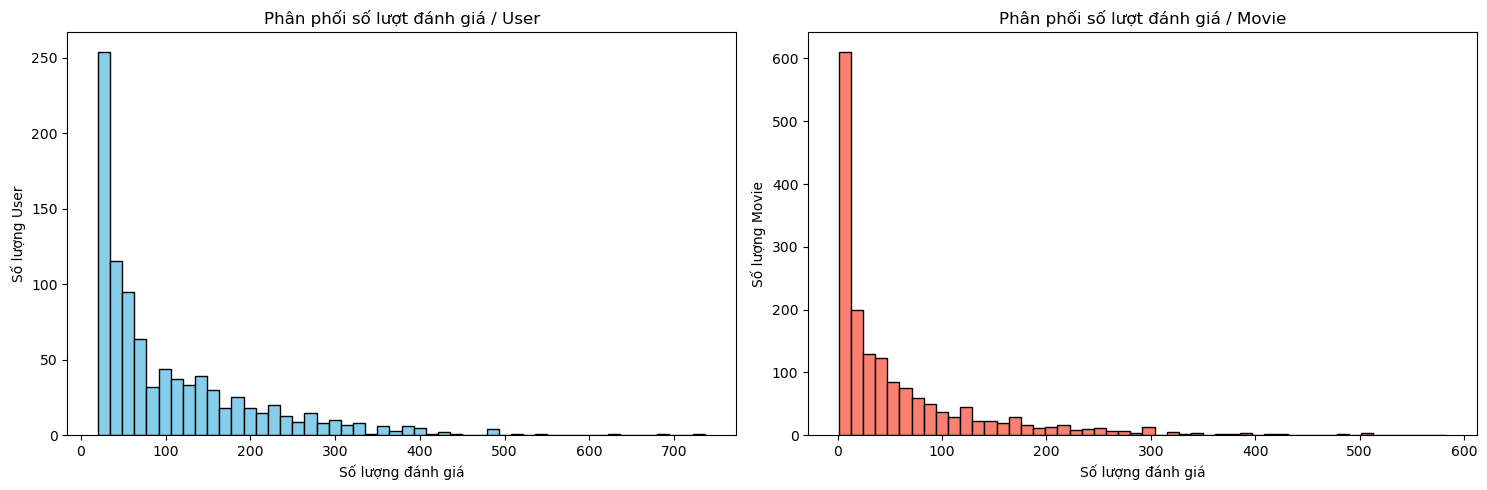

--- Thống kê User ---
count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: count, dtype: float64

--- Thống kê Movie ---
count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
Name: count, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Phân phối số lượt đánh giá theo từng User
user_counts = ratings_df.groupBy("user_id").count().toPandas()
# Phân phối số lượt đánh giá theo từng Movie
movie_counts = ratings_df.groupBy("movie_id").count().toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ User
ax1.hist(user_counts['count'], bins=50, color='skyblue', edgecolor='black')
ax1.set_title('Phân phối số lượt đánh giá / User')
ax1.set_xlabel('Số lượng đánh giá')
ax1.set_ylabel('Số lượng User')

# Biểu đồ Movie
ax2.hist(movie_counts['count'], bins=50, color='salmon', edgecolor='black')
ax2.set_title('Phân phối số lượt đánh giá / Movie')
ax2.set_xlabel('Số lượng đánh giá')
ax2.set_ylabel('Số lượng Movie')

plt.tight_layout()
plt.show()

# In ra số liệu cụ thể để nhận xét
print("--- Thống kê User ---")
print(user_counts['count'].describe())
print("\n--- Thống kê Movie ---")
print(movie_counts['count'].describe())


* **Hiệu ứng Long-tail (Đuôi dài):** Cả 2 biểu đồ đều lệch trái cực mạnh. 
  * **Về phía User:** Hơn 75% người dùng đánh giá ít hơn 148 bộ phim (dựa trên mốc 75%). Đa số người dùng rất lười đánh giá.
  * **Về phía Phim:** Hơn 75% số lượng phim nhận được ít hơn 80 lượt đánh giá. Đa phần các bộ phim rất ít người biết đến.
* **Vấn đề Khởi động lạnh (Cold-Start Problem):**
  * *Người dùng mới:* Khi một user mới đăng ký, họ chưa có đánh giá nào (0 điểm dữ liệu). Thuật toán ALS (Collaborative Filtering) sẽ bị "mù" và không biết gợi ý gì.
  * *Phim mới:* Khi một bộ phim mới ra rạp, chưa ai xem và đánh giá, phim đó sẽ vĩnh viễn không được gợi ý cho ai.
  * *Cách giải quyết:* Chúng ta có thể dùng Content-based filtering (gợi ý dựa trên thể loại) hoặc đề xuất các phim "TOP Trending" cho người dùng mới.

# 3. TOP 10 bộ phim phổ biến nhất

In [5]:
query_popular = """
    SELECT movie_title as `Tên phim`, COUNT(*) as `Số lượt đánh giá`
    FROM movies_ratings
    GROUP BY movie_title
    ORDER BY `Số lượt đánh giá` DESC
    LIMIT 10
"""
# toPandas() giúp bảng hiển thị đẹp như Excel trong Jupyter
spark.sql(query_popular).toPandas()


,Tên phim,Số lượt đánh giá
0,Star Wars (1977),583
1,Contact (1997),509
2,Fargo (1996),508
3,Return of the Jedi (1983),507
4,Liar Liar (1997),485
5,"English Patient, The (1996)",481
6,Scream (1996),478
7,Toy Story (1995),452
8,Air Force One (1997),431
9,Independence Day (ID4) (1996),429


* **Hiệu ứng đuôi dài (Long-tail effect):** Các phim phổ biến nhất thu hút sự chú ý khổng lồ.
  * Top 1: *Star Wars (1977)* với 583 lượt đánh giá
  * Top 2: *Contact (1997)* với 509 lượt đánh giá
  * Top 3: *Fargo (1996)* với 508 lượt đánh giá

# 4. TOP 10 bộ phim hay nhất (Lọc phim rác)

In [6]:
query_best = """
    SELECT movie_title as `Tên phim`, 
           ROUND(AVG(rating), 2) as `Điểm trung bình`, 
           COUNT(*) as `Số lượt đánh giá`
    FROM movies_ratings
    GROUP BY movie_title
    HAVING `Số lượt đánh giá` >= 100
    ORDER BY `Điểm trung bình` DESC
    LIMIT 10
"""
spark.sql(query_best).toPandas()


,Tên phim,Điểm trung bình,Số lượt đánh giá
0,"Close Shave, A (1995)",4.49,112
1,Schindler's List (1993),4.47,298
2,"Wrong Trousers, The (1993)",4.47,118
3,Casablanca (1942),4.46,243
4,"Shawshank Redemption, The (1994)",4.45,283
5,Rear Window (1954),4.39,209
6,"Usual Suspects, The (1995)",4.39,267
7,Star Wars (1977),4.36,583
8,12 Angry Men (1957),4.34,125
9,Citizen Kane (1941),4.29,198


* **Sự cần thiết của bộ lọc (`HAVING >= 100`):** Nếu không giới hạn số lượt đánh giá tối thiểu, danh sách này sẽ bị thao túng bởi những bộ phim lạ chỉ có 1–2 người chấm 5 sao. Việc lọc này giúp tìm ra những tác phẩm thực sự có chất lượng và nhận diện tốt từ số đông.


* **Chất lượng đỉnh cao vượt thời gian:** Bộ phim dẫn đầu là hoạt hình ngắn *Close Shave, A (1995)* với điểm số ấn tượng **4.49**. Các vị trí tiếp theo đều gọi tên những tượng đài kinh điển toàn cầu như *Schindler's List (1993)* và *Casablanca (1942)*.


* **Giao điểm giữa "Hay nhất" và "Phổ biến nhất":** Chỉ có duy nhất bom tấn **Star Wars (1977)** là tác phẩm xuất hiện xuất sắc ở cả hai danh sách Top 10 phổ biến nhất và Top 10 hay nhất (xếp vị trí thứ 8 với điểm số 4.36).

# 5. Biểu đồ phân bố điểm số

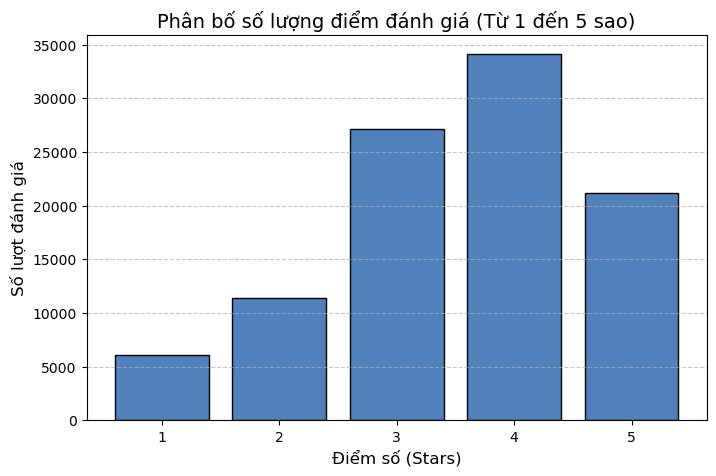

In [7]:
import matplotlib.pyplot as plt

query_dist = """
    SELECT rating, COUNT(*) as count
    FROM movies_ratings
    GROUP BY rating
    ORDER BY rating
"""
dist_df = spark.sql(query_dist).toPandas()

# Code vẽ biểu đồ cột (Bar Chart)
plt.figure(figsize=(8, 5))
plt.bar(dist_df['rating'], dist_df['count'], color='#4F81BD', edgecolor='black')
plt.title('Phân bố số lượng điểm đánh giá (Từ 1 đến 5 sao)', fontsize=14)
plt.xlabel('Điểm số (Stars)', fontsize=12)
plt.ylabel('Số lượt đánh giá', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


* **Tâm lý người dùng (Positivity Bias):** Biểu đồ cột cho thấy xu hướng lệch phải rõ rệt. Người dùng có xu hướng chỉ đánh giá những bộ phim mà họ thấy hay. Các phim dở thường bị ngó lơ.
  * **5 sao:** ~21.2%
  * **4 sao:** ~34.1% (Nhiều nhất)
  * **3 sao:** ~27.1%
  * **1-2 sao:** Chiếm tỷ lệ rất thấp (~17%)

# 6. Nạp dữ liệu Khách hàng và Vẽ biểu đồ Giới tính

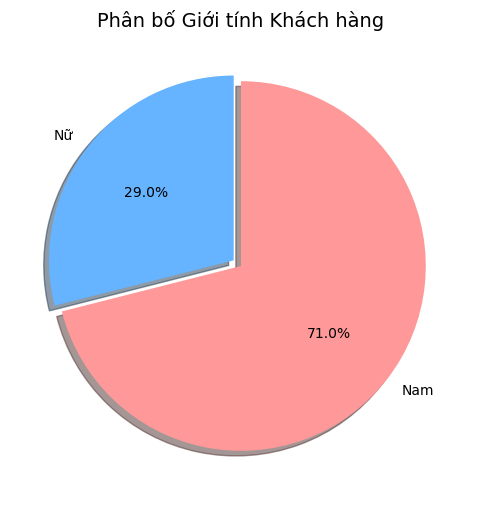

In [8]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# Cấu trúc của file u.user (Thông tin khách hàng)
user_schema = StructType([
    StructField("user_id", IntegerType(), True),
    StructField("age", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("occupation", StringType(), True),
    StructField("zip_code", StringType(), True)
])

# Nạp dữ liệu
user_path = "../../data/ml-100k/u.user"
users_df = spark.read.csv(user_path, sep="|", schema=user_schema)
users_df.createOrReplaceTempView("users")

# Phân tích Giới tính (M: Nam, F: Nữ)
query_gender = "SELECT gender, COUNT(*) as count FROM users GROUP BY gender"
gender_df = spark.sql(query_gender).toPandas()

# Thay đổi nhãn cho đẹp
gender_df['gender'] = gender_df['gender'].replace({'M': 'Nam', 'F': 'Nữ'})

# Vẽ biểu đồ tròn (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(gender_df['count'], labels=gender_df['gender'], autopct='%1.1f%%', 
        colors=['#66b3ff', '#ff9999'], startangle=90, shadow=True, explode=(0.05, 0))
plt.title('Phân bố Giới tính Khách hàng', fontsize=14)
plt.show()


* **Mất cân bằng giới tính nghiêm trọng:** Biểu đồ tròn cho thấy lượng khách hàng **Nam giới chiếm áp đảo với 71%**, trong khi **Nữ giới chỉ chiếm 29%**. Tập dữ liệu này phản ánh hành vi xem phim bị chi phối mạnh mẽ bởi tệp người dùng nam.
* **Định hình xu hướng gợi ý:** Do nam giới chiếm đa số, các thuật toán gợi ý mặc định (nếu không được tinh chỉnh) sẽ có xu hướng ưu tiên đề xuất các bộ phim hợp gu nam giới (như hành động, khoa học viễn tưởng) cho toàn bộ hệ thống.
* **Xử lý dữ liệu thô chuẩn xác:** Việc chủ động định nghĩa cấu trúc dữ liệu (`StructType`) khi đọc file CSV ngăn cách bằng ký tự `|` giúp Spark ép kiểu chuẩn ngay từ đầu, tăng hiệu năng và tránh lỗi dữ liệu trống (null values).

# 7. Vẽ biểu đồ Phân bố Độ tuổi 

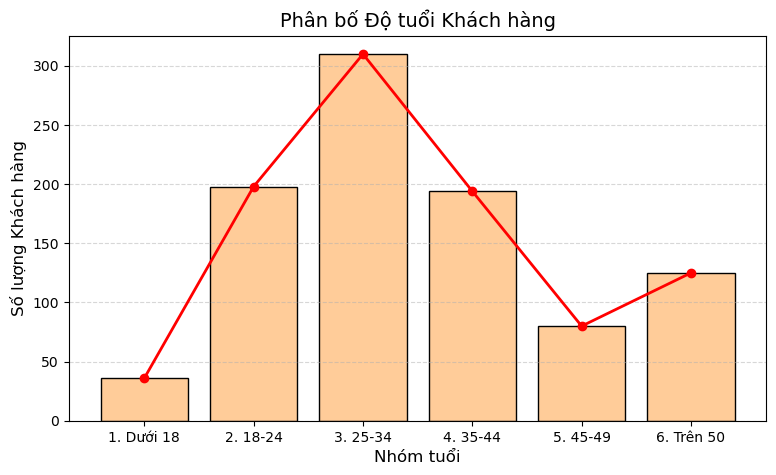

In [9]:
query_age = """
    SELECT 
        CASE 
            WHEN age < 18 THEN '1. Dưới 18'
            WHEN age BETWEEN 18 AND 24 THEN '2. 18-24'
            WHEN age BETWEEN 25 AND 34 THEN '3. 25-34'
            WHEN age BETWEEN 35 AND 44 THEN '4. 35-44'
            WHEN age BETWEEN 45 AND 49 THEN '5. 45-49'
            WHEN age >= 50 THEN '6. Trên 50'
        END as age_group,
        COUNT(*) as count
    FROM users
    GROUP BY age_group
    ORDER BY age_group
"""
age_df = spark.sql(query_age).toPandas()

# Vẽ biểu đồ đường và cột kết hợp
plt.figure(figsize=(9, 5))
plt.bar(age_df['age_group'], age_df['count'], color='#ffcc99', edgecolor='black')
plt.plot(age_df['age_group'], age_df['count'], color='red', marker='o', linewidth=2) # Thêm đường trend
plt.title('Phân bố Độ tuổi Khách hàng', fontsize=14)
plt.xlabel('Nhóm tuổi', fontsize=12)
plt.ylabel('Số lượng Khách hàng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


* **Độ tuổi vàng xem phim (25–34 tuổi):** Biểu đồ cột kết hợp đường trend thể hiện rất rõ nhóm người dùng từ **25 đến 34 tuổi chiếm số lượng đông đảo nhất** (vượt mốc 300 khách hàng). Đây là tệp khán giả chính, có xu hướng tự chủ tài chính và tần suất giải trí cao.
* **Tập trung vào giới trẻ & trung niên:** Lượng khách hàng phân rã mạnh về hai đầu (Dưới 18 tuổi và Từ 45–49 tuổi chiếm tỷ lệ thấp). Phần lớn người dùng của hệ thống nằm trong dải tuổi lao động năng động từ **18 đến 44 tuổi**.
* **Xử lý nhóm tuổi thông minh bằng SQL:** Việc sử dụng cấu trúc `CASE WHEN` trực tiếp trong câu lệnh Spark SQL giúp bạn gom nhóm dữ liệu thô (binning) cực kỳ nhanh gọn và khoa học ngay từ tầng xử lý dữ liệu lớn, giúp việc trực quan hóa bằng Matplotlib sau đó trở nên nhẹ nhàng.
* **Tệp khách hàng trẻ năng động này:** (kết hợp với yếu tố 71% là Nam giới ở bước trước) sẽ quyết định rất lớn đến "gu" phim chung của toàn hệ thống!

# 8. Biểu đồ Cột ngang (Horizontal Bar) - Top Thể loại phim

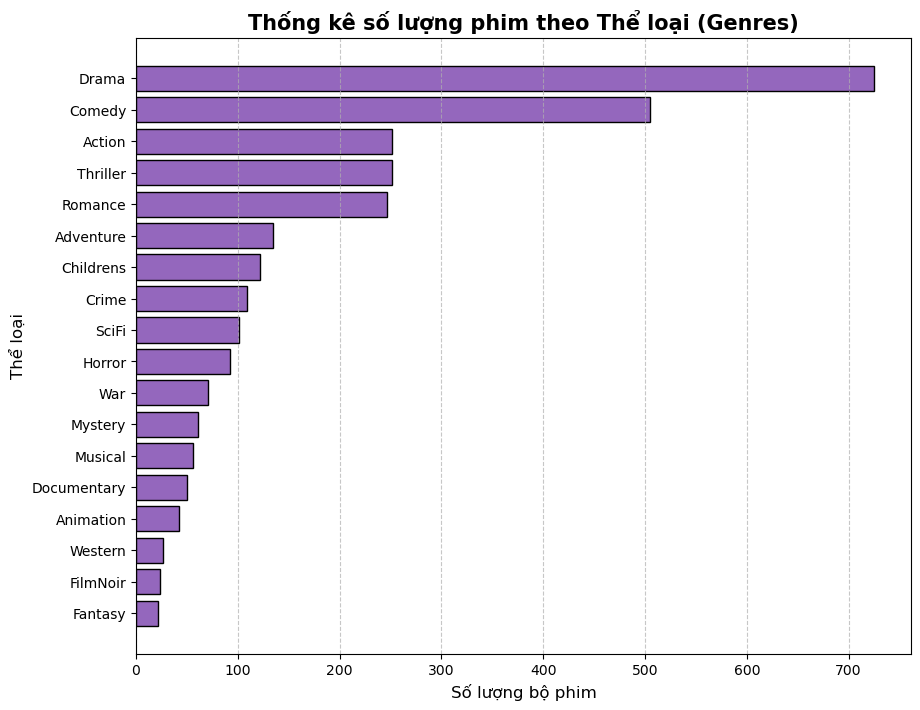

In [10]:
from pyspark.sql.functions import sum as _sum

# Danh sách 24 cột của bảng u.item (từ cột thứ 6 trở đi là thể loại)
item_cols = ["movie_id", "movie_title", "release_date", "video_release_date", "imdb_url", 
             "unknown", "Action", "Adventure", "Animation", "Childrens", "Comedy", "Crime", 
             "Documentary", "Drama", "Fantasy", "FilmNoir", "Horror", "Musical", "Mystery", 
             "Romance", "SciFi", "Thriller", "War", "Western"]

# Đọc file raw u.item
movies_raw = spark.read.csv("../../data/ml-100k/u.item", sep="|", encoding="ISO-8859-1")

# Gán tên cột cho DataFrame
for i, col_name in enumerate(item_cols):
    movies_raw = movies_raw.withColumnRenamed(f"_c{i}", col_name)

# Tính tổng số lượng phim cho từng thể loại (từ cột 'Action' đến 'Western')
genre_cols = item_cols[6:]
exprs = [_sum(movies_raw[c].cast("int")).alias(c) for c in genre_cols]
genre_df = movies_raw.agg(*exprs).toPandas()

# Sắp xếp để vẽ biểu đồ ngang cho đẹp
genre_series = genre_df.iloc[0].sort_values()

# Vẽ biểu đồ ngang (Horizontal Bar)
plt.figure(figsize=(10, 8))
plt.barh(genre_series.index, genre_series.values, color='#9467bd', edgecolor='black')
plt.title('Thống kê số lượng phim theo Thể loại (Genres)', fontsize=15, fontweight='bold')
plt.xlabel('Số lượng bộ phim', fontsize=12)
plt.ylabel('Thể loại', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


* **Sự thống trị của Drama và Comedy:** Biểu đồ cột ngang cho thấy **Drama (Phim chính kịch)** là thể loại phổ biến nhất với số lượng áp đảo (vượt mốc 700 bộ phim), theo sau là **Comedy (Phim hài)** với hơn 500 phim. Hai thể loại này chiếm phần lớn kho phim của hệ thống.
* **Đặc trưng dữ liệu One-Hot Encoding:** Cấu trúc file gốc lưu thể loại phim dưới dạng các cột nhị phân (0 hoặc 1). Việc bạn dùng `_sum(movies_raw[c].cast("int"))` là kỹ thuật chuẩn để gộp (aggregate) và đếm tổng số lượng phim thuộc từng thể loại cực kỳ hiệu quả trong Spark.
* **Sắp xếp hợp lý khi trực quan hóa:** Việc sử dụng `.sort_values()` trước khi vẽ đồ thị nằm ngang (`plt.barh`) giúp các thanh dữ liệu được xếp từ thấp đến cao một cách trực quan, giúp người xem dễ dàng nhận biết ngay thứ hạng của các thể loại phim.

# 9. Biểu đồ Cột ngang - Thống kê Nghề nghiệp (Occupation)

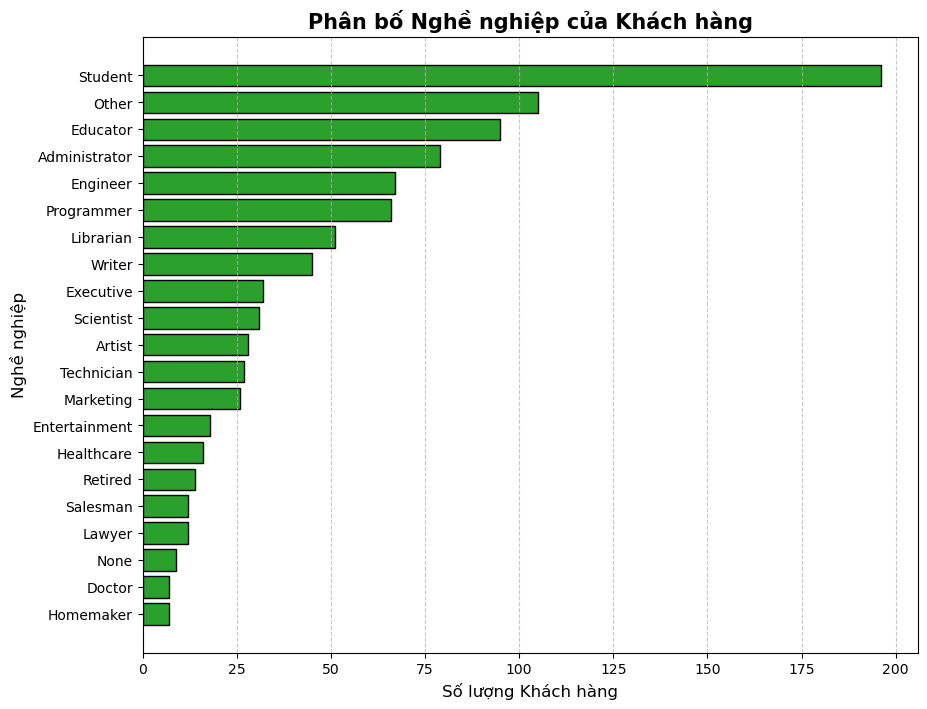

In [11]:
# Truy vấn nhóm theo nghề nghiệp và đếm số lượng
query_occ = """
    SELECT occupation, COUNT(*) as count 
    FROM users 
    GROUP BY occupation 
    ORDER BY count
"""
occ_df = spark.sql(query_occ).toPandas()

# Viết hoa chữ cái đầu cho đẹp
occ_df['occupation'] = occ_df['occupation'].str.capitalize()

# Vẽ biểu đồ ngang
plt.figure(figsize=(10, 8))
plt.barh(occ_df['occupation'], occ_df['count'], color='#2ca02c', edgecolor='black')
plt.title('Phân bố Nghề nghiệp của Khách hàng', fontsize=15, fontweight='bold')
plt.xlabel('Số lượng Khách hàng', fontsize=12)
plt.ylabel('Nghề nghiệp', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


* **Học sinh/Sinh viên chiếm ngôi vương:** Biểu đồ cột ngang cho thấy **Student (Học sinh/Sinh viên)** là nhóm ngành nghề xuất hiện nhiều nhất với số lượng áp đảo (gần 200 người). Điều này hoàn toàn khớp với biểu đồ phân bố độ tuổi trẻ (18–34) đã phân tích ở bước trước.
* **Đặc trưng tệp khách hàng tri thức/kỹ thuật:** Theo sau nhóm học sinh và nhóm "Other" là các khối ngành có tính chuyên môn cao như **Educator (Giáo dục)**, **Administrator (Quản trị)**, **Engineer (Kỹ sư)** và **Programmer (Lập trình viên)**. Tệp người dùng này thường có xu hướng đóng góp những đánh giá mang tính logic và chi tiết hơn.
* **Xử lý chuỗi thông minh (`.str.capitalize()`):** Đoạn code xử lý Python rất tinh tế khi dùng lệnh viết hoa chữ cái đầu cho cột `occupation`. Việc này giúp chuẩn hóa dữ liệu hiển thị trên nhãn (label) của biểu đồ, mang lại giao diện báo cáo sạch sẽ, chuyên nghiệp và đồng bộ.

Sự kết hợp giữa: **Nam giới (71%) + Trẻ tuổi (25-34) + Học sinh/Dân kỹ thuật** chính là bức chân dung khách hàng hoàn chỉnh nhất của hệ thống này!